In [71]:
# Block 1: Data Loading and Imports Libraries

import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import warnings

# Uyarıları azaltmak için (analiz sonucunu etkilemez)
warnings.filterwarnings("ignore", category=FutureWarning, module="pingouin")


# Load the processed summary data
# Her katılımcı için 6 koşulun (2 Cinsiyet x 3 Duygu) ortalamasını içeren dosya
input_file = "processed_data/final_summary_for_anova.csv"
df_summary = pd.read_csv(input_file)

print("Data loaded successfully for statistical testing.")
print(f"Number of participants in analysis: {df_summary['participant'].nunique()}")

Data loaded successfully for statistical testing.
Number of participants in analysis: 18


In [72]:
# Blok 2: Column naming update
# Veri setindeki gender isimlendirmesi karışık olduğu için düzeltmek gerekiyordu.
df_summary = df_summary.rename(columns={
    'Gender': 'face_gender',
    'gender': 'participant_gender'
})

print("Yeni Sütun İsimleri:", df_summary.columns.tolist())


Yeni Sütun İsimleri: ['participant', 'face_gender', 'Emotion', 'accuracy', 'mean_rt', 'participant_gender', 'age', 'handedness']


**NOT: Gender-gender karmaşıklığını yukarıdaki kodla giderdik.**

In [73]:
# Block 3: 

# Duyguları valansı(duygu yükü) esas alarak sırlıyoruz. Verinin eksik olup olmadığını kontrol ediyoruz.

# Çıktılarda sayıları daha okunaklı göstermek için
pd.set_option("display.float_format", "{:.8f}".format)

# Basic sanity checks
emotion_order = ['Angry', 'Neutral', 'Happy']
gender_order = ['Female', 'Male']  # only for consistent display

df_summary['Emotion'] = pd.Categorical(df_summary['Emotion'], categories=emotion_order, ordered=True)
df_summary['face_gender'] = pd.Categorical(df_summary['face_gender'], categories=gender_order, ordered=True)

# Each participant should have 6 rows (2*3)
counts = df_summary.groupby('participant').size()
print("Participants:", df_summary['participant'].nunique())
print("Rows per participant (should all be 6):")
print(counts.value_counts().sort_index())

# Check missing cells
print("\nMissing accuracy cells:", df_summary['accuracy'].isna().sum())


Participants: 18
Rows per participant (should all be 6):
6    18
Name: count, dtype: int64

Missing accuracy cells: 0


In [74]:
# Block 4: Katılımcı Demografisi ve Örneklem Özeti
# Bu blok, analize dahil edilen katılımcıların demografik dağılımını (cinsiyet, el kullanımı, yaş) özetlemek amacıyla oluşturulmuştur.

print("=== Katılımcı Demografik Özeti ===")

# Her katılımcı için 6 satır veri bulunduğundan, tekrar eden kayıtları önlemek için katılımcı bazlı tekilleştirme yapılır.
participant_demographics = df_summary.drop_duplicates(subset=['participant'])

# 1. Toplam Katılımcı Sayısı
total_n = len(participant_demographics)
print(f"Toplam Katılımcı Sayısı (N): {total_n}")

# 2. Cinsiyet Dağılımı
# 'participant_gender' sütunu üzerinden hesaplanır.
p_gender_counts = participant_demographics['participant_gender'].value_counts()
print("\nKatılımcı Cinsiyet Dağılımı:")
for gender, count in p_gender_counts.items():
    percentage = (count / total_n) * 100
    print(f"- {gender}: {count} kişi (%{percentage:.1f})")

# 3. El Kullanımı (Handedness) Dağılımı
p_hand_counts = participant_demographics['handedness'].value_counts()
print("\nEl Kullanımı (Handedness) Dağılımı:")
for hand, count in p_hand_counts.items():
    percentage = (count / total_n) * 100
    print(f"- {hand}: {count} kişi (%{percentage:.1f})")

# 4. Yaş İstatistiği (Eğer veri setinde mevcutsa)
if 'age' in participant_demographics.columns:
    mean_age = participant_demographics['age'].mean()
    std_age = participant_demographics['age'].std()
    min_age = participant_demographics['age'].min()
    max_age = participant_demographics['age'].max()
    print(f"\nYaş İstatistikleri: Ortalama = {mean_age:.2f} (SS = {std_age:.2f}), Aralık: {min_age}-{max_age}")

print("==================================")

=== Katılımcı Demografik Özeti ===
Toplam Katılımcı Sayısı (N): 18

Katılımcı Cinsiyet Dağılımı:
- Female: 10 kişi (%55.6)
- Male: 8 kişi (%44.4)

El Kullanımı (Handedness) Dağılımı:
- Right: 16 kişi (%88.9)
- Left: 2 kişi (%11.1)

Yaş İstatistikleri: Ortalama = 25.33 (SS = 7.83), Aralık: 22-50


**Yukarıdaki bilgiler doğrultusunda verileri cinsiyete göre incelemenin mümkün olduğunu(10 kadın ve 8 erkek, dengeli), ancak sağlaklık-solaklık açısından incelemenin mantıklı olmadığını söyleyebiliriz(16 sağlak ve 2 solak, dengesiz dağılım).**

**Ayrıca yaş dağılımının homojen olmamasından dolayı(çok ciddi bir çoğunluk genç) araştırmamıza yaşla ilgili ilişkileri dahil etmedik.**

In [75]:
# Block 5:
# Analiz öncesi eksik veri kontrolü ve normallik kontrolü yapılır.
# Örneklem küçük olduğu için Shapiro-Wilk testi kullanılır.

from scipy.stats import shapiro

print("\n=== Eksik Veri Kontrolü ===")
print("Missing RT cells:", df_summary['mean_rt'].isna().sum())
print("Missing accuracy cells:", df_summary['accuracy'].isna().sum())

# Güvenlik: RT/Accuracy sayısal değilse dönüştür
df_summary['mean_rt'] = pd.to_numeric(df_summary['mean_rt'], errors='coerce')
df_summary['accuracy'] = pd.to_numeric(df_summary['accuracy'], errors='coerce')

# Shapiro-Wilk'i katılımcı bazlı genel ortalamalar üzerinde yapmak daha anlamlıdır
# (Koşul sayısı az olduğundan hücre bazlı testler gürültülü olabilir.)
rt_by_participant = df_summary.groupby('participant')['mean_rt'].mean().dropna()
acc_by_participant = df_summary.groupby('participant')['accuracy'].mean().dropna()

print("\n=== Normallik (Shapiro-Wilk) ===")

if len(rt_by_participant) >= 3:
    stat_rt, p_rt = shapiro(rt_by_participant)
    print(f"RT (katılımcı ortalamaları) -> W={stat_rt:.3f}, p={p_rt:.4f}")
else:
    print("RT için Shapiro uygulanamadı (yetersiz veri).")

if len(acc_by_participant) >= 3:
    stat_acc, p_acc = shapiro(acc_by_participant)
    print(f"Accuracy (katılımcı ortalamaları) -> W={stat_acc:.3f}, p={p_acc:.4f}")
else:
    print("Accuracy için Shapiro uygulanamadı (yetersiz veri).")



=== Eksik Veri Kontrolü ===
Missing RT cells: 0
Missing accuracy cells: 0

=== Normallik (Shapiro-Wilk) ===
RT (katılımcı ortalamaları) -> W=0.858, p=0.0113
Accuracy (katılımcı ortalamaları) -> W=0.944, p=0.3414


**Not: Eksik veri kontrolünde hem RT hem de accuracy için özet tabloda boş hücre bulunmadığı görülmüştür (Missing RT cells = 0, Missing accuracy cells = 0). Normallik kontrolü Shapiro-Wilk testi ile katılımcı ortalamaları üzerinden yapılmıştır (n<50 olduğu için). Sonuçlara göre RT ortalamaları normal dağılım varsayımını sağlamamaktadır (p=0.0113<0.05), accuracy ortalamaları ise normal dağılımla uyumludur (p=0.3414>0.05). Bu nedenle sonraki analizlerde RT için sonuçlar yorumlanırken dağılım sapması dikkate alınmış, ana analiz olarak ders kapsamında istenen RM-ANOVA yaklaşımı uygulanmıştır.**


In [76]:
# Block 6:
# Ana analiz olarak 2x3 Repeated Measures ANOVA uygulanır.
# (within: face_gender x Emotion, subject: participant)

import os

results_folder = os.path.join("results", "main_analysis")
os.makedirs(results_folder, exist_ok=True)

print("\n=== 2x3 RM-ANOVA: RT (mean_rt) ===")
rm_rt = pg.rm_anova(
    data=df_summary,
    dv='mean_rt',
    within=['face_gender', 'Emotion'],
    subject='participant',
    detailed=True
)
print(rm_rt)
rm_rt.to_csv(os.path.join(results_folder, "rm_anova_rt.csv"), index=False)

print("\n=== 2x3 RM-ANOVA: Accuracy (accuracy) ===")
rm_acc = pg.rm_anova(
    data=df_summary,
    dv='accuracy',
    within=['face_gender', 'Emotion'],
    subject='participant',
    detailed=True
)
print(rm_acc)
rm_acc.to_csv(os.path.join(results_folder, "rm_anova_accuracy.csv"), index=False)

print(f"\nRM-ANOVA tabloları kaydedildi: {results_folder}")


# Çıktıları daha okunaklı yazdırmak ve p-değerlerini özetlemek için yardımcı fonksiyonlar

def prettify_anova_table(anova_df):
    # Sayısal kolonları 8 hane ile yuvarlayıp yazdırma için kopya oluşturur
    pretty = anova_df.copy()
    for col in ['SS', 'MS', 'F', 'p-unc', 'p-GG-corr', 'ng2', 'eps']:
        if col in pretty.columns:
            pretty[col] = pd.to_numeric(pretty[col], errors='coerce').round(8)
    return pretty

def summarize_pvalues(anova_df, dv_name, alpha=0.05):
    # Her etki için p değerini (varsa GG düzeltmeli) seçip anlamlılık tablosu üretir
    summary_rows = []
    for _, row in anova_df.iterrows():
        source = row['Source']

        # Öncelik: GG düzeltmeli p varsa onu kullan, yoksa p-unc
        if 'p-GG-corr' in anova_df.columns and pd.notna(row.get('p-GG-corr', None)):
            p_val = float(row['p-GG-corr'])
            p_type = "p-GG-corr"
        else:
            p_val = float(row['p-unc'])
            p_type = "p-unc"

        summary_rows.append({
            "DV": dv_name,
            "Etki": source,
            "p_türü": p_type,
            "p_değeri": round(p_val, 8),
            "Sonuç": "anlamlı" if p_val < alpha else "anlamlı değil"
        })

    return pd.DataFrame(summary_rows)

# --- RT ---
print("\n=== 2x3 RM-ANOVA: RT (mean_rt) ===")
rm_rt = pg.rm_anova(
    data=df_summary,
    dv='mean_rt',
    within=['face_gender', 'Emotion'],
    subject='participant',
    detailed=True
)

print(prettify_anova_table(rm_rt).to_string(index=False))
rm_rt.to_csv(os.path.join(results_folder, "rm_anova_rt.csv"), index=False, float_format="%.8f")

# --- Accuracy ---
print("\n=== 2x3 RM-ANOVA: Accuracy (accuracy) ===")
rm_acc = pg.rm_anova(
    data=df_summary,
    dv='accuracy',
    within=['face_gender', 'Emotion'],
    subject='participant',
    detailed=True
)

print(prettify_anova_table(rm_acc).to_string(index=False))
rm_acc.to_csv(os.path.join(results_folder, "rm_anova_accuracy.csv"), index=False, float_format="%.8f")

# --- Özet tablo: p-değerleri ve anlamlılık ---
print("\n=== Özet: p-değerleri ve anlamlılık (alpha=0.05) ===")
summary_rt = summarize_pvalues(rm_rt, dv_name="RT", alpha=0.05)
summary_acc = summarize_pvalues(rm_acc, dv_name="Accuracy", alpha=0.05)

summary_all = pd.concat([summary_rt, summary_acc], ignore_index=True)

# Okunaklı yazdırma
print(summary_all.to_string(index=False))

# İstersen dosyaya da kaydedelim
summary_all.to_csv(os.path.join(results_folder, "anova_significance_summary.csv"), index=False, float_format="%.8f")




=== 2x3 RM-ANOVA: RT (mean_rt) ===
                  Source         SS  ddof1  ddof2         MS          F  \
0            face_gender 0.21285090      1     17 0.21285090 4.43717387   
1                Emotion 0.04054801      2     34 0.02027401 2.13872191   
2  face_gender * Emotion 0.02173468      2     34 0.01086734 1.24542506   

       p-unc  p-GG-corr        ng2        eps  
0 0.05032626 0.05032626 0.03257822 1.00000000  
1 0.13338648 0.14490517 0.00637424 0.80530041  
2 0.30061726 0.29658766 0.00342688 0.81349705  

=== 2x3 RM-ANOVA: Accuracy (accuracy) ===
                  Source         SS  ddof1  ddof2         MS           F  \
0            face_gender 0.00300369      1     17 0.00300369  0.36394430   
1                Emotion 0.06014059      2     34 0.03007029 15.95321616   
2  face_gender * Emotion 0.14404615      2     34 0.07202307 29.21254642   

       p-unc  p-GG-corr        ng2        eps  
0 0.55428820 0.55428820 0.00870785 1.00000000  
1 0.00001298 0.00003889 0.1

**Not:**
**2x3 RM-ANOVA sonuçlarına göre RT (mean_rt) için yüz cinsiyeti (face_gender), duygu (Emotion) ve etkileşim (face_gender×Emotion) etkileri 0.05 anlamlılık düzeyinde istatistiksel olarak anlamlı bulunmamıştır. face_gender için p değeri 0.05’e çok yakın olsa da (p=0.0503), bu çalışma kapsamında “anlamlı” olarak değerlendirilmemiştir.**

**Accuracy (accuracy) için ise Emotion ana etkisi (p-GG-corr=0.00003889) ve face_gender×Emotion etkileşimi (p-GG-corr=0.00000009) anlamlıdır. Bu durum, doğruluğun duygu koşullarına göre değiştiğini ve bu değişimin uyaran yüz cinsiyetine bağlı olarak farklılaştığını göstermektedir. Sphericity düzeltmesi gereken durumlarda GG-düzeltilmiş p değerleri (p-GG-corr) raporlanmıştır.**


In [77]:
# Block 7 (G*Power - Accuracy):
# Accuracy için G*Power'a girilecek temel değerleri hesaplamak ve kaydetmek.
# Amaç: raporda kullanılan güç analizi parametrelerini şeffaf hale getirmek.

import numpy as np
import os

def cohens_f_from_eta2(eta2):
    # Cohen's f dönüşümü: f = sqrt(eta2 / (1 - eta2))
    # Burada eta2 olarak ng2 (yaklaşık) kullanıyoruz.
    if eta2 is None or np.isnan(eta2) or eta2 <= 0 or eta2 >= 1:
        return np.nan
    return float(np.sqrt(eta2 / (1.0 - eta2)))

def mean_offdiag_corr(df_wide):
    # Koşullar arası ortalama korelasyon (diagonal hariç)
    corr = df_wide.corr()
    vals = corr.values
    n = vals.shape[0]
    if n <= 1:
        return np.nan
    offdiag = vals[~np.eye(n, dtype=bool)]
    return float(np.nanmean(offdiag))

print("\n=== G*Power Parametreleri (Accuracy) ===")

# 1) Hangi etki için power raporlanacak?
# Etkileşim anlamlı çıktığı için genelde hedef olarak etkileşim seçilir.
target_effect = "face_gender * Emotion"

row = rm_acc[rm_acc["Source"] == target_effect]
if row.empty:
    raise ValueError(f"G*Power için hedef etki bulunamadı: {target_effect}")

row = row.iloc[0]

# 2) Etki büyüklüğü (Cohen's f) - ng2 üzerinden yaklaşık
eta2_approx = float(row["ng2"]) if "ng2" in row.index and pd.notna(row["ng2"]) else np.nan
f_approx = cohens_f_from_eta2(eta2_approx)

# 3) Epsilon (RM-ANOVA çıktısından)
eps_val = float(row["eps"]) if "eps" in row.index and pd.notna(row["eps"]) else np.nan

# 4) Repeated measures korelasyonu (Accuracy için) - veriden hesaplanır
# Katılımcı x koşul wide tablo oluşturulur
tmp = df_summary.copy()
tmp["cond_label"] = tmp[["face_gender", "Emotion"]].astype(str).agg(" | ".join, axis=1)

acc_wide = tmp.pivot_table(
    index="participant",
    columns="cond_label",
    values="accuracy",
    aggfunc="mean"
)

corr_rm = mean_offdiag_corr(acc_wide)

# 5) G*Power için sabit bilgiler (tasarımdan gelir)
n_groups = 1
n_measurements = 6  # 2x3 = 6 koşul

print(f"Hedef etki: {target_effect}")
print(f"Yaklaşık eta^2 (ng2): {eta2_approx:.8f}")
print(f"Cohen's f (yaklaşık): {f_approx:.8f}")
print(f"Ölçümler arası ortalama korelasyon (r): {corr_rm:.8f}")
print(f"Nonsphericity correction (epsilon): {eps_val:.8f}")
print(f"Number of groups: {n_groups}")
print(f"Number of measurements: {n_measurements}")

# 6) Dosyaya kaydet (rapora eklemek için)
gpower_text = []
gpower_text.append("G*Power Parametreleri (Accuracy)")
gpower_text.append(f"Hedef etki: {target_effect}")
gpower_text.append(f"Yaklaşık eta^2 (ng2): {eta2_approx:.8f}")
gpower_text.append(f"Cohen's f (yaklaşık): {f_approx:.8f}")
gpower_text.append(f"Corr among repeated measures (r): {corr_rm:.8f}")
gpower_text.append(f"Nonsphericity correction (epsilon): {eps_val:.8f}")
gpower_text.append(f"Number of groups: {n_groups}")
gpower_text.append(f"Number of measurements: {n_measurements}")
gpower_text.append("")
gpower_text.append("G*Power ayarı önerisi:")
gpower_text.append("- Test family: F tests")
gpower_text.append("- Statistical test: ANOVA: Repeated measures, within factors")
gpower_text.append("- Type: A priori (required N) veya Post hoc (achieved power)")
gpower_text.append("- Alpha: 0.05, Power: 0.80 (a priori için)")

out_path = os.path.join(results_folder, "gpower_inputs_accuracy.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write("\n".join(gpower_text))

print(f"\nG*Power parametreleri kaydedildi: {out_path}")



=== G*Power Parametreleri (Accuracy) ===
Hedef etki: face_gender * Emotion
Yaklaşık eta^2 (ng2): 0.29640173
Cohen's f (yaklaşık): 0.64904975
Ölçümler arası ortalama korelasyon (r): -0.05633942
Nonsphericity correction (epsilon): 0.94683524
Number of groups: 1
Number of measurements: 6

G*Power parametreleri kaydedildi: results\main_analysis\gpower_inputs_accuracy.txt


**Not: Accuracy için G*Power’da “ANOVA: Repeated measures, within factors” kurulumu ile güç analizi yapılmıştır (α=0.05, hedef güç=0.80, 1 grup, 6 ölçüm ve ε değeri RM-ANOVA çıktısından alınmıştır). Mevcut örneklemden türetilen yaklaşık etki büyüklüğü (f) ve ölçümler arası ortalama korelasyon (r) kullanıldığında, G*Power çıktısı gerekli toplam örneklem büyüklüğünü yaklaşık N=7 olarak vermiştir (actual power ≈ 0.82). Bu sonuç, etki büyüklüğünün mevcut veriden (observed/pilot temelli) elde edilmesine bağlıdır; dolayısıyla örneklem planlaması açısından sonuçlar temkinli yorumlanmalı ve bu durum raporda bir kısıt olarak belirtilmelidir. Bu çalışmada ders yönergesindeki minimum aralığa uygun olarak N=18 katılımcı ile analizler yürütülmüştür.**

In [78]:
# Block 8:
# Anlamlı sonuçlar için post-hoc karşılaştırmalar yapılır.
# Amaç: Hangi koşullar arasında fark olduğunu daha net görmek.

alpha = 0.05

def pick_p_value(row):
    # GG düzeltmeli p varsa onu kullan, yoksa p-unc kullan
    if 'p-GG-corr' in row and pd.notna(row['p-GG-corr']):
        return float(row['p-GG-corr'])
    return float(row['p-unc'])

def get_effect_p(anova_table, effect_name):
    row = anova_table[anova_table['Source'] == effect_name]
    if row.empty:
        return None
    return pick_p_value(row.iloc[0])

# --- RT için post-hoc kontrol (bu veri setinde anlamlı çıkmadığı için genelde çalışmaz) ---
print("\n=== Post-hoc Kontrol (RT) ===")
p_rt_face = get_effect_p(rm_rt, 'face_gender')
p_rt_emotion = get_effect_p(rm_rt, 'Emotion')
p_rt_inter = get_effect_p(rm_rt, 'face_gender * Emotion')

if (p_rt_face is not None and p_rt_face < alpha) or (p_rt_emotion is not None and p_rt_emotion < alpha) or (p_rt_inter is not None and p_rt_inter < alpha):
    print("RT için anlamlı etki bulundu. Post-hoc analiz yapılabilir.")
else:
    print("RT için anlamlı etki yok. Post-hoc uygulanmadı.")

# --- Accuracy için post-hoc ---
print("\n=== Post-hoc Kontrol (Accuracy) ===")
p_acc_face = get_effect_p(rm_acc, 'face_gender')
p_acc_emotion = get_effect_p(rm_acc, 'Emotion')
p_acc_inter = get_effect_p(rm_acc, 'face_gender * Emotion')

# 1) Etkileşim anlamlıysa: en doğru yorum için basit etkiler yapılır
# (Her face_gender içinde Emotion seviyeleri karşılaştırılır.)
if p_acc_inter is not None and p_acc_inter < alpha:
    print("Accuracy için etkileşim anlamlı. Her face_gender içinde Emotion karşılaştırmaları yapılacak.")

    face_levels = sorted(df_summary['face_gender'].astype(str).unique())

    for g in face_levels:
        df_sub = df_summary[df_summary['face_gender'].astype(str) == g].copy()

        posthoc_emotion = pg.pairwise_tests(
            data=df_sub,
            dv='accuracy',
            within='Emotion',
            subject='participant',
            padjust='holm',
            parametric=True
        )

        print(f"\nAccuracy post-hoc (Emotion) | face_gender = {g}")
        print(posthoc_emotion.to_string(index=False))

        out_name = f"posthoc_accuracy_emotion_within_face_gender_{g}.csv"
        posthoc_emotion.to_csv(os.path.join(results_folder, out_name), index=False, float_format="%.8f")

    print("\nPost-hoc çıktıları kaydedildi (Accuracy - basit etkiler).")

# 2) Etkileşim anlamlı değil ama Emotion ana etkisi anlamlıysa: genel Emotion karşılaştırmaları yapılır
elif p_acc_emotion is not None and p_acc_emotion < alpha:
    print("Accuracy için Emotion ana etkisi anlamlı. Genel Emotion karşılaştırmaları yapılacak.")

    posthoc_acc_emotion = pg.pairwise_tests(
        data=df_summary,
        dv='accuracy',
        within='Emotion',
        subject='participant',
        padjust='holm',
        parametric=True
    )

    print("\nAccuracy post-hoc (Emotion) - Genel")
    print(posthoc_acc_emotion.to_string(index=False))

    out_name = "posthoc_accuracy_emotion_overall.csv"
    posthoc_acc_emotion.to_csv(os.path.join(results_folder, out_name), index=False, float_format="%.8f")

    print("\nPost-hoc çıktısı kaydedildi (Accuracy - genel).")

else:
    print("Accuracy için post-hoc gerektiren anlamlı bir durum yok.")



=== Post-hoc Kontrol (RT) ===
RT için anlamlı etki yok. Post-hoc uygulanmadı.

=== Post-hoc Kontrol (Accuracy) ===
Accuracy için etkileşim anlamlı. Her face_gender içinde Emotion karşılaştırmaları yapılacak.

Accuracy post-hoc (Emotion) | face_gender = Female
Contrast       A       B  Paired  Parametric           T         dof alternative      p-unc     p-corr p-adjust      BF10      hedges
 Emotion   Angry Neutral    True        True -6.35901996 17.00000000   two-sided 0.00000713 0.00001426     holm  3001.077 -2.30947778
 Emotion   Angry   Happy    True        True -9.45266767 17.00000000   two-sided 0.00000004 0.00000011     holm 3.845e+05 -2.36763259
 Emotion Neutral   Happy    True        True  0.13775528 17.00000000   two-sided 0.89205231 0.89205231     holm     0.245  0.04158093

Accuracy post-hoc (Emotion) | face_gender = Male
Contrast       A       B  Paired  Parametric           T         dof alternative      p-unc     p-corr p-adjust   BF10      hedges
 Emotion   Angry Neutr

**Not: Post-hoc analizler yalnızca anlamlı RM-ANOVA sonuçları için uygulanmıştır. RT için ana analizde anlamlı etki bulunmadığı için post-hoc yapılmamıştır. Accuracy için ise face_gender×Emotion etkileşimi anlamlı olduğundan, etkileşimi yorumlayabilmek amacıyla basit etkiler analizi yapılmış ve her yüz cinsiyeti düzeyi (Female/Male) içinde Emotion seviyeleri ikili olarak karşılaştırılmıştır. Çoklu karşılaştırmalardan kaynaklanabilecek hatayı azaltmak için Holm düzeltmesi kullanılmıştır.**

**Sonuçlar, Female yüz koşulunda Angry’nin hem Neutral hem de Happy’den anlamlı biçimde farklı olduğunu, Neutral ile Happy arasında anlamlı fark olmadığını göstermektedir. Male yüz koşulunda ise Angry–Neutral ve Neutral–Happy karşılaştırmaları anlamlı iken, Angry–Happy karşılaştırması anlamlı değildir. Bu bulgular, doğruluk (accuracy) üzerindeki duygu etkisinin yüz cinsiyetine bağlı olarak değiştiğini desteklemektedir.**


In [79]:
# Block 9:
# Sonuçları daha anlaşılır kılmak için koşul ortalamaları özetlenir.
# Bu özet, raporda tablo olarak kullanılabilir.

print("\n=== Koşul Ortalamaları (Descriptive Statistics) ===")

# 1) Accuracy için koşul ortalamaları ve standart sapma
acc_desc = (
    df_summary
    .groupby(['face_gender', 'Emotion'], as_index=False, observed=False)
    .agg(
        mean_accuracy=('accuracy', 'mean'),
        std_accuracy=('accuracy', 'std'),
        n=('accuracy', 'count')
    )
)

# 2) RT için koşul ortalamaları ve standart sapma
rt_desc = (
    df_summary
    .groupby(['face_gender', 'Emotion'], as_index=False, observed=False)
    .agg(
        mean_rt=('mean_rt', 'mean'),
        std_rt=('mean_rt', 'std'),
        n=('mean_rt', 'count')
    )
)

# Sayıları daha okunaklı göstermek için yuvarla
acc_desc['mean_accuracy'] = acc_desc['mean_accuracy'].round(8)
acc_desc['std_accuracy'] = acc_desc['std_accuracy'].round(8)

rt_desc['mean_rt'] = rt_desc['mean_rt'].round(8)
rt_desc['std_rt'] = rt_desc['std_rt'].round(8)

print("\n--- Accuracy (koşul bazında) ---")
print(acc_desc.to_string(index=False))

print("\n--- RT (koşul bazında) ---")
print(rt_desc.to_string(index=False))

# Dosyaya kaydet
acc_desc.to_csv(os.path.join(results_folder, "descriptives_accuracy_by_condition.csv"), index=False, float_format="%.8f")
rt_desc.to_csv(os.path.join(results_folder, "descriptives_rt_by_condition.csv"), index=False, float_format="%.8f")

print("\nDescriptive tablolar kaydedildi.")



=== Koşul Ortalamaları (Descriptive Statistics) ===

--- Accuracy (koşul bazında) ---
face_gender Emotion  mean_accuracy  std_accuracy  n
     Female   Angry     0.84734815    0.05332652 18
     Female Neutral     0.96099740    0.04226884 18
     Female   Happy     0.95929175    0.03782502 18
       Male   Angry     0.95324886    0.06733150 18
       Male Neutral     0.88946795    0.07924719 18
       Male   Happy     0.95656270    0.05691370 18

--- RT (koşul bazında) ---
face_gender Emotion    mean_rt     std_rt  n
     Female   Angry 0.97086816 0.29108605 18
     Female Neutral 0.94839430 0.30531929 18
     Female   Happy 0.90792884 0.27193675 18
       Male   Angry 0.84230951 0.20222401 18
       Male Neutral 0.88409800 0.24380305 18
       Male   Happy 0.83441881 0.13989232 18

Descriptive tablolar kaydedildi.


**Not: Koşul ortalamaları 2x3 tasarıma göre (face_gender × Emotion) hesaplanmıştır ve her hücrede 18 katılımcı bulunmaktadır (n=18). Accuracy sonuçlarında Female yüz koşulunda Angry duygu koşulunun ortalama doğruluğu Neutral ve Happy’e göre daha düşük görünürken; Male yüz koşulunda Neutral koşulunun ortalama doğruluğu diğer duygu koşullarına göre daha düşüktür. RT için koşul ortalamaları genel olarak 0.83–0.97 saniye aralığındadır; Female yüz koşullarında ortalama RT’ler Male yüz koşullarına kıyasla daha yüksek görünmektedir. Bu tablolar, RM-ANOVA ve post-hoc sonuçlarının yönünü daha anlaşılır hale getirmek amacıyla özet istatistik olarak rapora eklenmiştir.**


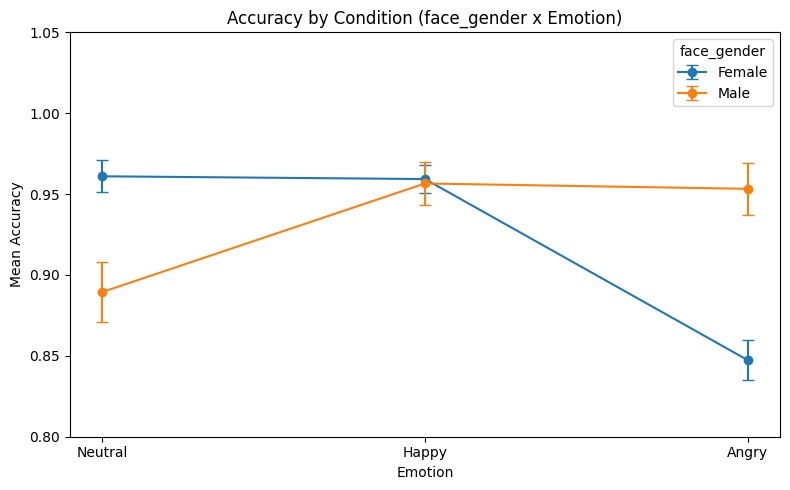

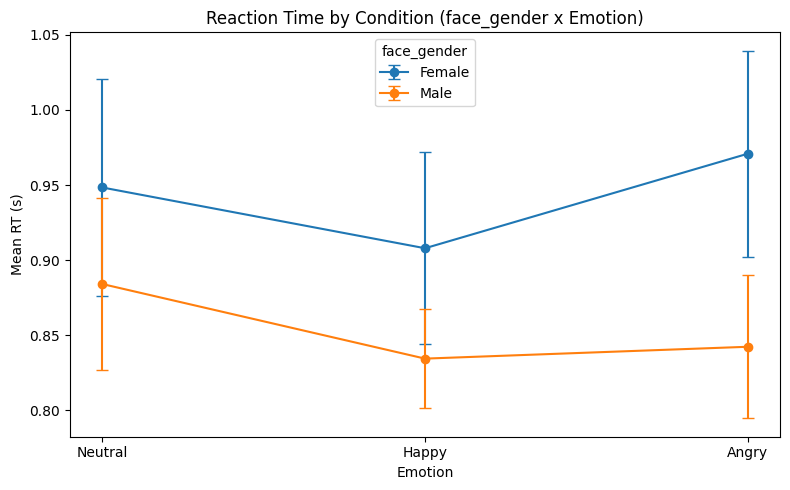


Figürler kaydedildi: results\main_analysis\figures


In [80]:
# Block 10:
# Sonuçları görsel olarak sunmak için temel grafikler oluşturulur.
# Amaç: Koşul ortalamalarının yönünü daha anlaşılır hale getirmek.

import matplotlib.pyplot as plt
import numpy as np
import os

# Emotion sırası raporda karışmasın diye sabitlenir
emotion_order = ["Neutral", "Happy", "Angry"]

def add_sem(df, mean_col, std_col, n_col, out_col):
    df[out_col] = df[std_col] / np.sqrt(df[n_col])
    return df

# SEM hesapla
acc_plot_df = acc_desc.copy()
rt_plot_df = rt_desc.copy()

acc_plot_df = add_sem(acc_plot_df, "mean_accuracy", "std_accuracy", "n", "sem_accuracy")
rt_plot_df = add_sem(rt_plot_df, "mean_rt", "std_rt", "n", "sem_rt")

# Emotion sırasını uygula
acc_plot_df["Emotion"] = pd.Categorical(acc_plot_df["Emotion"], categories=emotion_order, ordered=True)
rt_plot_df["Emotion"] = pd.Categorical(rt_plot_df["Emotion"], categories=emotion_order, ordered=True)

acc_plot_df = acc_plot_df.sort_values(["face_gender", "Emotion"])
rt_plot_df = rt_plot_df.sort_values(["face_gender", "Emotion"])

# Çıktı klasörü
fig_folder = os.path.join(results_folder, "figures")
os.makedirs(fig_folder, exist_ok=True)

# --- Accuracy grafiği ---
plt.figure(figsize=(8, 5))
for g in sorted(acc_plot_df["face_gender"].astype(str).unique()):
    sub = acc_plot_df[acc_plot_df["face_gender"].astype(str) == g]
    plt.errorbar(
        sub["Emotion"].astype(str),
        sub["mean_accuracy"],
        yerr=sub["sem_accuracy"],
        marker="o",
        linestyle="-",
        capsize=4,
        label=g
    )

plt.xlabel("Emotion")
plt.ylabel("Mean Accuracy")
plt.title("Accuracy by Condition (face_gender x Emotion)")
plt.ylim(0.8, 1.05)
plt.legend(title="face_gender")
plt.tight_layout()
plt.savefig(os.path.join(fig_folder, "figure_accuracy_means.png"), dpi=300)
plt.show()

# --- RT grafiği ---
plt.figure(figsize=(8, 5))
for g in sorted(rt_plot_df["face_gender"].astype(str).unique()):
    sub = rt_plot_df[rt_plot_df["face_gender"].astype(str) == g]
    plt.errorbar(
        sub["Emotion"].astype(str),
        sub["mean_rt"],
        yerr=sub["sem_rt"],
        marker="o",
        linestyle="-",
        capsize=4,
        label=g
    )

plt.xlabel("Emotion")
plt.ylabel("Mean RT (s)")
plt.title("Reaction Time by Condition (face_gender x Emotion)")
plt.legend(title="face_gender")
plt.tight_layout()
plt.savefig(os.path.join(fig_folder, "figure_rt_means.png"), dpi=300)
plt.show()

print(f"\nFigürler kaydedildi: {fig_folder}")


**Not: Bu figürlerde 2x3 tasarım kapsamında (face_gender × Emotion) koşul ortalamaları görsel olarak sunulmuştur. Noktalar koşul ortalamalarını, hata çubukları ise ortalamanın standart hatasını (SEM) göstermektedir. Accuracy grafiğinde çizgilerin paralel olmaması, doğruluk üzerindeki duygu etkisinin yüz cinsiyetine göre değiştiğini (etkileşim) görsel olarak desteklemektedir. Özellikle Female yüz koşulunda Angry durumunda doğruluk belirgin biçimde düşerken, Male yüz koşulunda en düşük doğruluk Neutral koşulunda gözlenmektedir. RT grafiğinde ise koşullar arasında küçük farklılıklar olsa da genel desenin daha sınırlı olduğu görülmektedir; bu durum RT için ana analizde anlamlı etki bulunmamasıyla tutarlıdır. Accuracy grafiğinde tüm değerler 0.8’in üzerinde olduğu için eksen aralığı okunabilirliği artırmak amacıyla 0.8–1.05 olarak sınırlandırılmıştır.**


In [81]:
# Block 11:
# Rapor yazımını kolaylaştırmak için, ana sonuç cümleleri otomatik üretilir.
# Amaç: F, serbestlik dereceleri ve p-değerlerini elle taşırken hata yapmamak.

import os

def get_p_for_report(row):
    # GG düzeltmeli p değeri varsa onu kullanıyoruz, yoksa p-unc kullanıyoruz
    if 'p-GG-corr' in row.index and pd.notna(row['p-GG-corr']):
        return float(row['p-GG-corr'])
    return float(row['p-unc'])

def format_p(p):
    # p değerini raporda okunaklı göstermek için
    if p < 0.0001:
        return "< 0.0001"
    return f"= {p:.6f}"

def extract_effect_stats(anova_df, effect_name):
    row = anova_df[anova_df['Source'] == effect_name].iloc[0]
    F = float(row['F'])
    df1 = int(row['ddof1'])
    df2 = int(row['ddof2'])
    p = get_p_for_report(row)
    ng2 = float(row['ng2']) if 'ng2' in row.index and pd.notna(row['ng2']) else None
    eps = float(row['eps']) if 'eps' in row.index and pd.notna(row['eps']) else None
    return F, df1, df2, p, ng2, eps

def build_report_text(dv_name, anova_df):
    lines = []
    lines.append(f"{dv_name} için 2x3 RM-ANOVA sonuçları:")

    for effect in ['face_gender', 'Emotion', 'face_gender * Emotion']:
        F, df1, df2, p, ng2, eps = extract_effect_stats(anova_df, effect)

        # Etki adı daha okunaklı olsun
        if effect == 'face_gender':
            effect_label = "face_gender ana etkisi"
        elif effect == 'Emotion':
            effect_label = "Emotion ana etkisi"
        else:
            effect_label = "face_gender × Emotion etkileşimi"

        # Cümle
        if ng2 is not None:
            lines.append(
                f"- {effect_label}: F({df1}, {df2}) = {F:.4f}, p {format_p(p)}, ng2 = {ng2:.4f}"
            )
        else:
            lines.append(
                f"- {effect_label}: F({df1}, {df2}) = {F:.4f}, p {format_p(p)}"
            )

        # Sphericity düzeltmesi bilgisi (varsa)
        if effect != 'face_gender' and eps is not None:
            lines.append(f"  (GG epsilon = {eps:.4f}, p değeri GG-düzeltilmiş olarak raporlanmıştır.)")

    return "\n".join(lines)

# Metinleri üret
rt_text = build_report_text("RT (mean_rt)", rm_rt)
acc_text = build_report_text("Accuracy (accuracy)", rm_acc)

report_text = []
report_text.append(rt_text)
report_text.append("")  # boş satır
report_text.append(acc_text)

final_report_text = "\n".join(report_text)

# Ekrana bas
print("\n=== Rapor için otomatik sonuç cümleleri ===")
print(final_report_text)

# Dosyaya kaydet
out_path = os.path.join(results_folder, "report_snippets.txt")
with open(out_path, "w", encoding="utf-8") as f:
    f.write(final_report_text)

print(f"\nRapor metni kaydedildi: {out_path}")



=== Rapor için otomatik sonuç cümleleri ===
RT (mean_rt) için 2x3 RM-ANOVA sonuçları:
- face_gender ana etkisi: F(1, 17) = 4.4372, p = 0.050326, ng2 = 0.0326
- Emotion ana etkisi: F(2, 34) = 2.1387, p = 0.144905, ng2 = 0.0064
  (GG epsilon = 0.8053, p değeri GG-düzeltilmiş olarak raporlanmıştır.)
- face_gender × Emotion etkileşimi: F(2, 34) = 1.2454, p = 0.296588, ng2 = 0.0034
  (GG epsilon = 0.8135, p değeri GG-düzeltilmiş olarak raporlanmıştır.)

Accuracy (accuracy) için 2x3 RM-ANOVA sonuçları:
- face_gender ana etkisi: F(1, 17) = 0.3639, p = 0.554288, ng2 = 0.0087
- Emotion ana etkisi: F(2, 34) = 15.9532, p < 0.0001, ng2 = 0.1496
  (GG epsilon = 0.8709, p değeri GG-düzeltilmiş olarak raporlanmıştır.)
- face_gender × Emotion etkileşimi: F(2, 34) = 29.2125, p < 0.0001, ng2 = 0.2964
  (GG epsilon = 0.9468, p değeri GG-düzeltilmiş olarak raporlanmıştır.)

Rapor metni kaydedildi: results\main_analysis\report_snippets.txt


**Not: RM-ANOVA sonuçları raporlanırken birden fazla seviyeye sahip faktörler (Emotion ve etkileşim) için GG-düzeltilmiş p değerleri kullanılmıştır. RT için hiçbir etki 0.05 düzeyinde anlamlı bulunmamış, face_gender ana etkisi ise sınırda kalmıştır (p=0.050326). Accuracy için Emotion ana etkisi ve face_gender×Emotion etkileşimi anlamlı bulunmuştur; bu durum doğruluğun duygu koşullarına göre değiştiğini ve bu değişimin yüz cinsiyetine bağlı olarak farklılaştığını göstermektedir.**